# Plot CF vs Reanalysis SST

Import Statements

In [12]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point
from scipy.interpolate import RegularGridInterpolator
import xarray as xr
import numpy as np
import fsspec
import os
import urllib.request

In [13]:
start = 2004
stop = 2023

# path
path = "/glade/work/smhenry/NeuralGCM/data/ERA5/"

# name
name_list_forcing_cf = [
    path + f"ERA5_forcing_{yr}_JASO_counterfactual.nc" for yr in range(start, stop + 1)
]

CACHE_DIR = "./data/ersstv6"
os.makedirs(CACHE_DIR, exist_ok=True)

BASE_URL = (
    "https://www.ncei.noaa.gov/data/"
    "sea-surface-temperature-extended-reconstructed/v6/access/"
)

years = range(1854, 1871)
months = [7, 8, 9, 10]  # JASO

local_paths = []
for year in years:
    for month in months:
        fname = f"ersst.v6.{year}{month:02d}.nc"
        local_path = os.path.join(CACHE_DIR, fname)
        if not os.path.exists(local_path):
            urllib.request.urlretrieve(BASE_URL + fname, local_path)
        local_paths.append(local_path)

In [14]:
# open counterfactual data
yr_SST_cf = []
for yr in range(start, stop + 1):
    yr_dat = (
        (xr.open_dataset(name_list_forcing_cf[yr - start]).sea_surface_temperature)
        .mean(dim="time")
        .assign_coords({"year": yr})
        .rename("SST [K]")
    )
    yr_SST_cf.append(yr_dat)


SST_cf = xr.concat(yr_SST_cf, dim="year").mean(dim="year")

In [15]:
SST_re_full = xr.open_mfdataset(
    local_paths, combine="by_coords", engine="netcdf4"
)

# ERSSTv6 keeps the same variable/dim naming convention as v5
# (sst variable, singleton "lev" dimension) — adjust here if that
# has changed in your actual v6 files
SST_re = SST_re_full["sst"]

# Climatological mean over JASO, 1854-1870
re_native = (
    SST_re.squeeze("lev")
    .sel(lat=slice(-50, 50))
    .mean("time")
)

In [16]:
print(SST_cf)
print(SST_re)

<xarray.DataArray 'SST [K]' (longitude: 256, latitude: 128)> Size: 131kB
array([[269.84958, 269.84958, 269.84958, ..., 268.2485 , 268.287  ,
        268.04187],
       [269.84958, 269.84958, 269.84958, ..., 268.24835, 268.2868 ,
        268.04083],
       [269.84958, 269.84958, 269.84958, ..., 268.2501 , 268.2871 ,
        268.0398 ],
       ...,
       [269.84958, 269.84958, 269.84958, ..., 268.24615, 268.2809 ,
        268.0406 ],
       [269.84958, 269.84958, 269.84958, ..., 268.2473 , 268.2833 ,
        268.0407 ],
       [269.84958, 269.84958, 269.84958, ..., 268.2477 , 268.2857 ,
        268.04138]], shape=(256, 128), dtype=float32)
Coordinates:
  * longitude  (longitude) float64 2kB 0.0 1.406 2.812 ... 355.8 357.2 358.6
  * latitude   (latitude) float64 1kB -88.93 -87.54 -86.14 ... 86.14 87.54 88.93
<xarray.DataArray 'sst' (time: 68, lev: 1, lat: 89, lon: 180)> Size: 4MB
dask.array<concatenate, shape=(68, 1, 89, 180), dtype=float32, chunksize=(1, 1, 89, 180), chunktype=numpy.nda

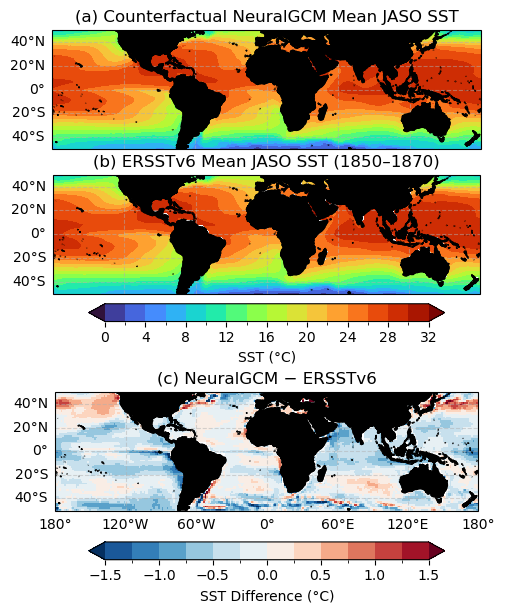

In [20]:
# NeuralGCM (°C)

cf_native = (SST_cf - 273.15).sel(latitude=slice(-50, 50))

# Interpolate ERSSTv6 to NeuralGCM grid
# (NO cyclic points used here)

interp = RegularGridInterpolator(
    (re_native.lat.values, re_native.lon.values),
    re_native.values,
    method="linear",
    bounds_error=False,
    fill_value=np.nan,
)

lat_grid, lon_grid = np.meshgrid(
    cf_native.latitude.values,
    cf_native.longitude.values,
    indexing="ij",
)

pts = np.column_stack((lat_grid.ravel(), lon_grid.ravel()))

re_interp = xr.DataArray(
    interp(pts).reshape(lat_grid.shape),
    coords={
        "latitude": cf_native.latitude.values,
        "longitude": cf_native.longitude.values,
    },
    dims=("latitude", "longitude"),
)

cf_interp = cf_native.transpose("latitude", "longitude")
diff = cf_interp - re_interp

# Add cyclic points ONLY to the two SST panels
# (Difference is plotted with pcolormesh)

cf_vals, cf_lon = add_cyclic_point(
    cf_native.values,
    coord=cf_native.longitude.values,
    axis=0,
)

cf_plot = xr.DataArray(
    cf_vals,
    coords={
        "longitude": cf_lon,
        "latitude": cf_native.latitude.values,
    },
    dims=("longitude", "latitude"),
)

re_vals, re_lon = add_cyclic_point(
    re_native.values,
    coord=re_native.lon.values,
    axis=1,
)

re_plot = xr.DataArray(
    re_vals,
    coords={
        "lat": re_native.lat.values,
        "lon": re_lon,
    },
    dims=("lat", "lon"),
)

# Force periodicity before adding cyclic point

diff_fixed = diff.copy()

# Make the easternmost column identical to the westernmost
diff_fixed.values[:, -1] = diff_fixed.values[:, 0]

diff_vals, diff_lon = add_cyclic_point(
    diff_fixed.values,
    coord=diff_fixed.longitude.values,
    axis=1,
)

diff_plot = xr.DataArray(
    diff_vals,
    coords={
        "latitude": diff_fixed.latitude.values,
        "longitude": diff_lon,
    },
    dims=("latitude", "longitude"),
)

# Plot

fig = plt.figure(figsize=(5, 6), constrained_layout=True)
gs = fig.add_gridspec(3, 1)

ax0 = fig.add_subplot(gs[0], projection=ccrs.PlateCarree())
ax1 = fig.add_subplot(gs[1], projection=ccrs.PlateCarree())
ax2 = fig.add_subplot(gs[2], projection=ccrs.PlateCarree())

land = cfeature.NaturalEarthFeature(
    "physical",
    "land",
    "50m",
    facecolor="black",
    edgecolor="black",
)

# Panel (a)

cf_plot.plot.contourf(
    ax=ax0,
    x="longitude",
    y="latitude",
    transform=ccrs.PlateCarree(),
    cmap="turbo",
    levels=np.arange(-0, 32+2, 2),
    extend="both",
    add_colorbar=False,
)

ax0.add_feature(land, zorder=100)
ax0.coastlines("50m", zorder=101)
ax0.set_title("(a) Counterfactual NeuralGCM Mean JASO SST")

gl = ax0.gridlines(draw_labels=True, linestyle="--", alpha=0.5)
gl.top_labels = False
gl.right_labels = False
gl.bottom_labels = False

# Panel (b)

pcm1 = re_plot.plot.contourf(
    ax=ax1,
    x="lon",
    y="lat",
    transform=ccrs.PlateCarree(),
    cmap="turbo",
    levels=np.arange(0, 32+2, 2),
    extend="both",
    add_colorbar=False,
)

ax1.add_feature(land, zorder=100)
ax1.coastlines("50m", zorder=101)
ax1.set_title("(b) ERSSTv6 Mean JASO SST (1850–1870)")

gl = ax1.gridlines(draw_labels=True, linestyle="--", alpha=0.5)
gl.top_labels = False
gl.right_labels = False
gl.bottom_labels = False

from matplotlib.colors import BoundaryNorm

# Panel (c)

levels_diff = np.arange(-1.5, 1.5 + .25, .25)
cmap_diff = plt.get_cmap("RdBu_r")
norm_diff = BoundaryNorm(levels_diff, ncolors=cmap_diff.N, extend="both")

pcm2 = ax2.pcolormesh(
    diff_plot.longitude.values,
    diff_plot.latitude.values,
    diff_plot.values,
    transform=ccrs.PlateCarree(),
    cmap=cmap_diff,
    norm=norm_diff,
    shading="auto",
)

ax2.add_feature(land, zorder=100)
ax2.coastlines("50m", zorder=101)
ax2.set_title("(c) NeuralGCM − ERSSTv6")

gl = ax2.gridlines(draw_labels=True, linestyle="--", alpha=0.5)
gl.top_labels = False
gl.right_labels = False

# Colorbar

cbar = fig.colorbar(
    pcm1,
    ax=ax1,
    orientation="horizontal",
    pad=0.08,
    shrink=0.85,
)

cbar.set_label("SST (°C)")

cbar = fig.colorbar(
    pcm2,
    ax=ax2,
    orientation="horizontal",
    pad=0.08,
    shrink=0.85,
)

cbar.set_label("SST Difference (°C)")

plt.savefig("./figs/SI_figure_cf_re_SST_LTM.png", dpi=600)
plt.show()